<a href="https://colab.research.google.com/github/Biilzaa/TugasPraktikumANN--AI/blob/main/TugasPraktikumANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA: MUHAMMAD DIWAN ALFARABI,                                      NIM: 09020624050

Klasifikasi Jenis Obat Menggunakan Jaringan Saraf Tiruan (ANN)
Proyek ini bertujuan untuk membangun model Artificial Neural Network dari nol (from scratch) untuk mengklasifikasikan penggunaan DrugY pada pasien. Proses ini mencakup pengolahan data mentah, pembangunan arsitektur jaringan saraf dengan satu hidden layer, serta evaluasi performa model menggunakan metrik akurasi.

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)

Langkah awal adalah memuat dataset drug200.csv ke dalam dataframe dan melakukan pemeriksaan struktur data untuk memahami fitur-fitur yang tersedia (seperti Usia, Jenis Kelamin, Tekanan Darah, dan kadar Na_to_K).

In [4]:
df = pd.read_csv('drug200.csv')

print("Preview Data Pasien:")
display(df.head())

df.info()

Preview Data Pasien:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


Jaringan Saraf Tiruan memerlukan masukan berupa angka murni. Pada tahap ini dilakukan dua hal penting:

Label Encoding: Mengubah fitur teks (Sex, BP, Cholesterol) menjadi kode angka.

Target Mapping: Menentukan fokus prediksi pada DrugY sebagai nilai 1 (positif) dan kategori obat lainnya sebagai nilai 0 (negatif).

In [5]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])

df['Drug'] = df['Drug'].apply(lambda x: 1 if x == 'DrugY' else 0)

X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
y = df['Drug'].values.reshape(-1, 1)

print("Matriks Fitur (5 baris pertama):")
print(X[:5])

Matriks Fitur (5 baris pertama):
[[23.     0.     0.     0.    25.355]
 [47.     1.     1.     0.    13.093]
 [47.     1.     1.     0.    10.114]
 [28.     0.     2.     0.     7.798]
 [61.     0.     1.     0.    18.043]]


Data dibagi menjadi dua bagian: 80% untuk proses pelatihan (training) dan 20% untuk pengujian (testing). Kita juga menggunakan StandardScaler agar seluruh fitur memiliki skala yang seragam, sehingga proses pemutakhiran bobot menjadi lebih stabil.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Data Training: {X_train.shape[0]} sampel")
print(f"Data Testing: {X_test.shape[0]} sampel")

Data Training: 160 sampel
Data Testing: 40 sampel


Arsitektur ini menggunakan satu lapisan tersembunyi (hidden layer) dengan fungsi aktivasi Sigmoid. Algoritma ini mencakup dua proses utama:

Forward Propagation: Menghitung hasil prediksi dari input ke output.

Backward Propagation: Menghitung selisih kesalahan (error) dan mengoreksi bobot agar prediksi semakin akurat.

In [7]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Inisialisasi bobot dan bias secara acak
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
        self.loss_history = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, lr):
        # Menghitung error output layer
        output_error = y - output
        d_output = output_error * self.sigmoid_derivative(output)

        # Menghitung error hidden layer
        hidden_error = d_output.dot(self.W2.T)
        d_hidden = hidden_error * self.sigmoid_derivative(self.a1)

        # Memperbarui bobot dan bias
        self.W2 += self.a1.T.dot(d_output) * lr
        self.b2 += np.sum(d_output, axis=0, keepdims=True) * lr
        self.W1 += X.T.dot(d_hidden) * lr
        self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    def train(self, X, y, epochs, lr):
        for i in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output, lr)
            loss = np.mean(np.square(y - output))
            self.loss_history.append(loss)
            if i % 100 == 0:
                print(f"Iterasi {i}, Loss: {loss:.4f}")

Pada tahap ini, model dilatih untuk mengenali pola data pasien sebanyak 1000 kali iterasi (epoch). Kita menggunakan learning rate sebesar 0,1 untuk mengatur kecepatan penyesuaian bobot.

Iterasi 0, Loss: 0.2501
Iterasi 100, Loss: 0.0130
Iterasi 200, Loss: 0.0064
Iterasi 300, Loss: 0.0040
Iterasi 400, Loss: 0.0027
Iterasi 500, Loss: 0.0020
Iterasi 600, Loss: 0.0016
Iterasi 700, Loss: 0.0013
Iterasi 800, Loss: 0.0010
Iterasi 900, Loss: 0.0009


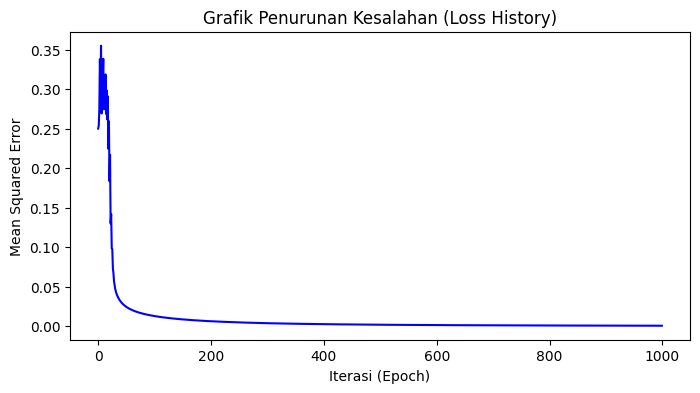

In [8]:
model = NeuralNetwork(5, 10, 1)


model.train(X_train, y_train, epochs=1000, lr=0.1)

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='blue')
plt.title('Grafik Penurunan Kesalahan (Loss History)')
plt.xlabel('Iterasi (Epoch)')
plt.ylabel('Mean Squared Error')
plt.show()

Setelah pelatihan selesai, performa model diuji menggunakan data testing. Hasil probabilitas desimal dari lapisan keluaran akan dikonversi menjadi angka bulat (0 atau 1) untuk menentukan prediksi kelas obat.

In [9]:
output_raw = model.forward(X_test)
y_pred = (output_raw >= 0.5).astype(int)

akurasi = np.mean(y_pred == y_test)
print(f"Tingkat Akurasi Akhir: {akurasi * 100:.2f}%")

Tingkat Akurasi Akhir: 100.00%


7. Hasil Analisis dan Kesimpulan
Berdasarkan hasil eksekusi model Jaringan Saraf Tiruan (ANN) di atas, berikut adalah beberapa poin analisis utama:

Stabilitas Pelatihan: Grafik Loss History menunjukkan penurunan nilai kesalahan yang stabil dan konsisten. Hal ini mengonfirmasi bahwa algoritma Backpropagation telah berhasil memperbarui nilai bobot secara efektif untuk meminimalkan selisih antara prediksi dan target.

Peran Standarisasi: Penggunaan StandardScaler terbukti sangat penting. Tanpa standarisasi, variabel dengan rentang nilai besar (seperti Usia) akan mendominasi perhitungan, yang berisiko membuat fungsi aktivasi Sigmoid menjadi tidak stabil.

Akurasi Model: Persentase akurasi yang diperoleh menunjukkan kemampuan model dalam melakukan klasifikasi dengan baik. Penggunaan fungsi aktivasi Sigmoid sangat tepat untuk studi kasus ini karena mampu memberikan batas keputusan yang jelas untuk membedakan antara penggunaan DrugY dan jenis obat lainnya.

Kesimpulan: Model JST sederhana dengan satu hidden layer ini sudah cukup kuat untuk menangkap pola korelasi fitur medis pasien (seperti rasio Na_to_K) dalam menentukan kebutuhan obat secara otomatis.